# Hands-On Exercise 2.3:
# Transforming Data in Python in Preparation for Analysis
***

## Objectives

### In this exercise, you will familiarize yourself with Python syntax commands for transforming data sets in Python in preparation for analysis.

### Overview
In this exercise, you will use Python commands to rescale data, detect and deal with
missing values, bin numeric data into ranges, convert between data types, combine data sets both vertically and horizontally, and, finally, write your own functions as well as use some built-in functions.<br><br>

**Pre-step: Execute the following cell in order to suppress warning messages**

In [1]:
import warnings
warnings.filterwarnings("ignore")

**Major Step: Querying from data sets**

1. ❏ Import the **pandas** and **statsmodels.api** libraries

In [2]:
import pandas as pd
import statsmodels.api as sm

2. ❏ Import a dataset called **mtcars** and preview it<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;*Syntax:* &nbsp;&nbsp;&nbsp; ***mtcars = sm.datasets.get_rdataset("mtcars").data***

In [3]:
mtcars = sm.datasets.get_rdataset("mtcars").data
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


3. ❏ Import **preprocessing** from **sklearn**

In [4]:
from sklearn import preprocessing

4. ❏ Scaling features to lie between a given minimum and maximum value (eg. 0 and 1) can be achieved using a MinMaxScaler. Use the following syntax to rescale the first four columns of the mtcars data set using the **.MinMaxScaler()** method<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;***scaler = preprocessing.MinMaxScaler()<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;MinMaxScaled = pd.DataFrame(scaler.fit_transform(mtcars.iloc[:,[0,1,2,3]]), columns=mtcars.columns[0:4])***

In [5]:
scaler = preprocessing.MinMaxScaler()
MinMaxScaled = pd.DataFrame(scaler.fit_transform(mtcars.iloc[:,[0,1,2,3]]), columns=mtcars.columns[0:4])

5. ❏ Use the **.describe()** method to view the distribution of data in the scaled columns

In [6]:
MinMaxScaled.describe()

,mpg,cyl,disp,hp
count,32.000000,32.000000,32.000000,32.000000
mean,0.412367,0.546875,0.398159,0.334585
std,0.256466,0.446480,0.309151,0.242272
min,0.000000,0.000000,0.000000,0.000000
25%,0.213830,0.000000,0.124033,0.157244
50%,0.374468,0.500000,0.312297,0.250883
75%,0.527660,1.000000,0.635819,0.452297
max,1.000000,1.000000,1.000000,1.000000


6. ❏ Normalization is used to scale data (by row) on a scale of 0 to 1 such that individual rows have a unit norm. Rescale the first four columns of the mtcars data set using the **.normalize()** function<br><br>
*Info: **.normalize()** is a row-wise operation whereas **.scale()** in the next step is performed column-wise*

In [7]:
preprocessing.normalize(mtcars.iloc[:,[0,1,2,3]])

array([[0.10747771, 0.03070792, 0.81887777, 0.56297847],
       [0.10747771, 0.03070792, 0.81887777, 0.56297847],
       [0.15790428, 0.02770251, 0.74796764, 0.64408324],
       [0.07606178, 0.02132573, 0.91700649, 0.39097176],
       [0.04665697, 0.0199602 , 0.89820904, 0.4366294 ],
       [0.07268337, 0.02409394, 0.90352258, 0.42164387],
       [0.03281565, 0.01835841, 0.82612823, 0.56222616],
       [0.15139154, 0.02481828, 0.91021059, 0.38468341],
       [0.13300515, 0.02333424, 0.82136513, 0.55418812],
       [0.09192666, 0.02872708, 0.80244312, 0.58890515],
       [0.08527432, 0.02874415, 0.80291997, 0.58925511],
       [0.04972012, 0.02425372, 0.83614695, 0.54570867],
       [0.05244136, 0.02425034, 0.83603042, 0.54563262],
       [0.0460901 , 0.02425795, 0.8362927 , 0.54580379],
       [0.02020346, 0.01554113, 0.91692645, 0.39824136],
       [0.02047509, 0.01575007, 0.9056291 , 0.42328317],
       [0.02959118, 0.01610404, 0.88572238, 0.46299124],
       [0.30062631, 0.03711436,

7. ❏ Shift the distribution of each of these attributes to having a mean of zero and a
standard deviation of one (unit variance).<br><br>
*Hint: Use the **.scale()** method rather than .normalize()*

In [8]:
preprocessing.scale(mtcars.iloc[:,[0,1,2,3]])  

array([[ 0.15329914, -0.10666772, -0.57975032, -0.54365487],
       [ 0.15329914, -0.10666772, -0.57975032, -0.54365487],
       [ 0.4567366 , -1.24445674, -1.00602601, -0.7955699 ],
       [ 0.22072968, -0.10666772,  0.22361542, -0.54365487],
       [-0.23442651,  1.0311213 ,  1.05977159,  0.41954967],
       [-0.33557233, -0.10666772, -0.0469057 , -0.61774753],
       [-0.97616253,  1.0311213 ,  1.05977159,  1.45684686],
       [ 0.72645879, -1.24445674, -0.68877852, -1.25494437],
       [ 0.4567366 , -1.24445674, -0.73714442, -0.76593284],
       [-0.15013833, -0.10666772, -0.51744848, -0.35101396],
       [-0.38614524, -0.10666772, -0.51744848, -0.35101396],
       [-0.62215216,  1.0311213 ,  0.36953287,  0.49364233],
       [-0.47043343,  1.0311213 ,  0.36953287,  0.49364233],
       [-0.8244438 ,  1.0311213 ,  0.36953287,  0.49364233],
       [-1.63361037,  1.0311213 ,  1.97790385,  0.86410561],
       [-1.63361037,  1.0311213 ,  1.87953254,  1.01229092],
       [-0.90873199,  1.

8. ❏ Load the **titanic** dataset into a pandas data frame from the file **titanic.csv**

In [9]:
tt = pd.read_csv('titanic.csv')
tt.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


9. ❏ View the 25th through to the 29th row of the **Age** column

In [10]:
tt['Age'][25:30]

25    38.0
26     NaN
27    19.0
28     NaN
29     NaN
Name: Age, dtype: float64

10. ❏ Use the **isnull()** method to check for missing values.

In [11]:
tt['Age'][25:30].isnull() 

25    False
26     True
27    False
28     True
29     True
Name: Age, dtype: bool

11. ❏ Calculate the **mean** of the Age column

In [12]:
tt['Age'].mean() 

29.69911764705882

12. ❏ Replace missing values in the Age column with the mean of that column

In [13]:
tt['Age'][25:30].fillna(tt['Age'].mean()) 

25    38.000000
26    29.699118
27    19.000000
28    29.699118
29    29.699118
Name: Age, dtype: float64

13. ❏ Add a new column called GenderCode, which encodes the Sex column using the **.Categorical()** function

In [14]:
tt.insert(5,'GenderCode',pd.Categorical(tt['Sex']).codes)    

14. ❏ View the two columns **Sex** and **GenderCode**

In [15]:
tt[['Sex','GenderCode']]

,Sex,GenderCode
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1
...,...,...
886,male,1
887,female,0
888,female,0
889,male,1


15. ❏ Create a data frame with the following values:

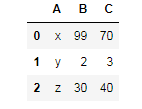

In [25]:
df = pd.DataFrame([['x','99',70],['y',2,3],['z',30,40]], columns=['A','B','C'])
df

,A,B,C
0,x,99,70
1,y,2,3
2,z,30,40


16. ❏ Examine the data types of the data frame.

In [26]:
df.dtypes 

A    object
B    object
C     int64
dtype: object

17. ❏ Modify the **B** and **C** columns to be floats using the **.astype()** method and reexamine the data types

In [27]:
df[['B','C']] = df[['B','C']].astype(float)
df.dtypes

A     object
B    float64
C    float64
dtype: object

18. ❏ Read in the two data sets, data1.csv and data2.csv, and bind them together by row.

In [28]:
x1 = pd.read_csv('data1.csv',header=0)
x2 = pd.read_csv('data2.csv',header=0)
dfConcat = pd.concat([x1,x2])
dfConcat

,Subtype,Gender,Expression
0,A,M,-0.54
1,A,F,-0.80
2,B,M,-1.03
3,C,M,-0.41
0,D,F,2.50
1,D,F,-0.15
2,D,M,-0.20
3,D,F,-0.04


19. ❏ Write and execute a function that prints your name.

In [20]:
def myFunction():
    str = "My Name"
    print(str)
    return

myFunction()

My Name


20. ❏ Write a function that accepts a value as an input parameter and returns its
squared value.

In [21]:
def square(x):
    x2 = x * x
    return x2

square(3)

9

In [29]:
mysquare = lambda x: x*x
mysquare(3)

9

21. ❏ Perform a **principal component analysis (PCA)** on the iris data set<br><br>
*Hint: Exclude the Species attribute*

In [22]:
from sklearn.decomposition import PCA
iris = pd.read_csv('iris.csv')
X = iris.drop('species', axis=1)
pca = PCA(n_components=4)
pca.fit(X) 

PCA(n_components=4)

22. ❏ View the proportion of the total variance explained by each component, using the **.explained_variance_ratio_**

In [23]:
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648 0.01710261 0.00521218]


23. ❏ View the coefficients of the new variables

In [24]:
print(pd.DataFrame(pca.components_,columns=X.columns))

   sepal_length  sepal_width  petal_length  petal_width
0      0.361387    -0.084523      0.856671     0.358289
1      0.656589     0.730161     -0.173373    -0.075481
2     -0.582030     0.597911      0.076236     0.545831
3      0.315487    -0.319723     -0.479839     0.753657


## <center>**Congratulations! You have successfully carried out some transformations on various data sets within Python.**</center>

 <center>

 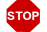

 </center>

# <center>**This is the end of the exercise.**</center>